# Notebook 01 - Data Exploration & Exploratory Data Analysis (EDA)   

This notebook establishes a foundational understanding of the dataset by analysing its structure, composition, and statistical properties. It begins with loading the clinical dataset and inspecting schema consistency, data types, and missing values. Particular emphasis is placed on the target variable (30-day readmission), including class distribution and imbalance assessment.

Exploratory analysis is performed on key attributes such as patient admissions, temporal patterns, and clinical variables. Visualisations are used to highlight distributions and correlations where relevant. The notebook also evaluates dataset scale and sampling considerations, ensuring feasibility for downstream modelling.

Overall, this stage ensures that the dataset is well-understood, highlights potential data quality issues, and informs preprocessing and modelling strategies.


## Library Imports and Environment Configuration

This section establishes the computational environment required for the exploratory analysis of the MIMIC-IV (v3.1) dataset. A range of scientific computing libraries are imported to facilitate data manipulation, numerical computation, and graphical visualisation. Specifically, *pandas* and *NumPy* support structured data processing, while *matplotlib* and *seaborn* provide functionality for producing statistical graphics.

To ensure modularity and reproducibility within the project structure, the parent project directory is appended to the system path. This enables access to configuration parameters defined externally within the `config` module, including directory paths for hospital data, intensive care data, and output plot storage. Centralising such configuration variables reduces redundancy and improves maintainability across the analytical workflow.

Visualisation parameters are configured globally to enforce stylistic consistency across all figures generated during analysis. Adjustments include figure resolution, font sizing, and axis spine visibility, which collectively enhance readability and presentation quality. A custom colour palette is also defined to maintain uniformity across plots.

Finally, runtime warnings are suppressed to prevent non-critical messages from interrupting the analytical process, and a confirmation message is printed to verify successful environment initialisation along with the designated output directory.

In [1]:
import sys
import os

# Append Project Root Directory to System Path
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Text Formatting Utility
import textwrap

# Suppress Non-Critical Runtime Warnings
import warnings
warnings.filterwarnings('ignore')

# Import Project Configuration Paths
from config import HOSP_DIR, ICU_DIR, PLOTS_DIR

# Create EDA Plot Save Directory
EDA_PLT = PLOTS_DIR / "eda"
EDA_PLT.mkdir(parents=True, exist_ok=True)

# Visualisation Styling Configuration
plt.rcParams.update({
    'figure.dpi' : 120,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'font.size' : 11,
})


# Custom Colour Palette 
PALETTE = [
    '#2E86AB',
    '#E84855',
    '#F4A261',
    '#2A9D8F',
    '#8338EC'
]

sns.set_palette(PALETTE)

## Data Loading and Temporal Variable Processing

This section loads the core clinical datasets required for subsequent exploratory analysis from the MIMIC-IV (v3.1) database. Multiple relational tables are imported, including patient demographics, hospital admissions, diagnostic codes, prescriptions, laboratory events, and intensive care unit (ICU) stay records. Supporting reference tables containing diagnostic and laboratory item metadata are also loaded to enable semantic interpretation of coded variables during analysis.

In addition, the *Online Medical Record (OMR)* table — introduced in later versions of MIMIC-IV — is incorporated to provide supplementary physiological measurements such as body mass index, blood pressure, and estimated glomerular filtration rate (eGFR). Inclusion of this dataset allows for richer characterisation of patient health status where available.

Following data ingestion, relevant temporal variables are converted to datetime format to ensure accurate chronological calculations. Coercion is applied during conversion to handle malformed or missing timestamps without interrupting execution. Length of stay (LOS) for hospital admissions is subsequently derived in days using the difference between discharge and admission timestamps, providing a clinically meaningful measure for downstream analysis.

This preprocessing stage establishes the foundational datasets and temporal features required for descriptive statistics, cohort construction, and outcome analysis in later sections.

In [2]:
# Data Loading: Core MIMIC-IV Tables
patients = pd.read_csv(f'{HOSP_DIR}/patients.csv.gz')
admissions = pd.read_csv(f'{HOSP_DIR}/admissions.csv.gz')
diagnoses = pd.read_csv(f'{HOSP_DIR}/diagnoses_icd.csv.gz')
prescriptions = pd.read_csv(f'{HOSP_DIR}/prescriptions.csv.gz')

labevents = pd.read_csv(
    f'{HOSP_DIR}/labevents.csv.gz',
    usecols=[
        'subject_id',
        'hadm_id',
        'itemid',
        'charttime',
        'valuenum'
    ],
    compression='gzip'
)

icustays = pd.read_csv(f'{ICU_DIR}/icustays.csv.gz')
d_icd_diag = pd.read_csv(f'{HOSP_DIR}/d_icd_diagnoses.csv.gz')
d_labitems = pd.read_csv(f'{HOSP_DIR}/d_labitems.csv.gz')
omr = pd.read_csv(f'{HOSP_DIR}/omr.csv.gz')


# Temporal Variable Conversion
for col in ['admittime', 'dischtime', 'deathtime']:
    if col in admissions.columns:
        admissions[col] = pd.to_datetime(
            admissions[col],
            errors='coerce'
        )

icustays['intime'] = pd.to_datetime(
    icustays['intime'],
    errors='coerce'
)

icustays['outtime'] = pd.to_datetime(
    icustays['outtime'],
    errors='coerce'
)

# Derived Feature: Hospital Length of Stay (Days)
admissions['los_days'] = (
    admissions['dischtime'] - admissions['admittime']
).dt.total_seconds() / 86400

## Data Integrity Checks and Dataset Dimension Verification

Following data ingestion and temporal preprocessing, additional validation steps are performed to confirm dataset integrity and structural consistency. The patient date of death variable is first converted to a datetime format to ensure compatibility with any subsequent mortality-related analyses.

A summary of dataset dimensions is then generated to provide an overview of the number of observations (rows) and variables (columns) contained within each table. Reporting dataset size is an important preliminary step in exploratory data analysis, as it supports transparency, facilitates computational planning, and enables early detection of unexpected discrepancies in data loading.

Finally, a schema validation check is conducted on the laboratory item reference table to confirm compatibility with the MIMIC-IV version used in this study. Specifically, the absence of the `loinc_code` variable is verified, as this field is not included in version 3.x of the dataset. This assertion acts as a safeguard against potential version mismatches that could otherwise introduce inconsistencies into downstream analyses.

Together, these checks ensure that the datasets have been loaded correctly and conform to the expected structural specifications prior to further analytical processing.

In [3]:
# # Temporal Conversion: Patient Mortality Variable
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')

# Dataset Dimension Summary
print(f'{"Table":<18} {"Rows":>10}  {"Cols":>6}')
print('-' * 40)

tables = [
    ('patients', patients),
    ('admissions', admissions),
    ('diagnoses', diagnoses),
    ('prescriptions', prescriptions),
    ('labevents', labevents),
    ('icustays', icustays),
    ('omr', omr)
]

for name, df in tables:
    print(f'{name:<18} {df.shape[0]:>10,}  {df.shape[1]:>6}')

# Schema Validation: Laboratory Items Reference Table
assert 'loinc_code' not in d_labitems.columns, (
    'loinc_code found -- check dataset version'
)

Table                    Rows    Cols
----------------------------------------
patients              364,627       6
admissions            546,028      17
diagnoses           6,364,488       5
prescriptions      20,292,611      21
labevents          158,374,764       5
icustays               94,458       8
omr                 7,753,027       5


## Patient Demographic Characteristics

Descriptive analysis of patient demographics provides essential context for understanding the composition of the study population and identifying potential sources of bias or heterogeneity. Figure 1 summarises the distribution of patient age, biological sex, and cohort year grouping within the MIMIC-IV (v3.1) dataset.

Age is represented using the *anchor age* variable, which reflects patient age at a reference time point rather than exact chronological age. Due to de-identification procedures applied within MIMIC-IV, ages above 89 years are top-coded and recorded as 91. This capping mechanism preserves privacy while maintaining approximate age structure for analytical purposes. The median age is displayed to provide a robust measure of central tendency that is less sensitive to skewness.

Sex distribution is examined to assess demographic balance within the cohort, while the anchor year grouping variable is analysed to evaluate temporal coverage of patient records. Notably, version 3.x of MIMIC-IV includes additional observations extending into the 2020–2022 period, which may reflect changes in clinical practice patterns or population characteristics over time.

The resulting visualisations provide an overview of cohort composition and support interpretation of subsequent analyses by establishing the demographic context of the dataset.

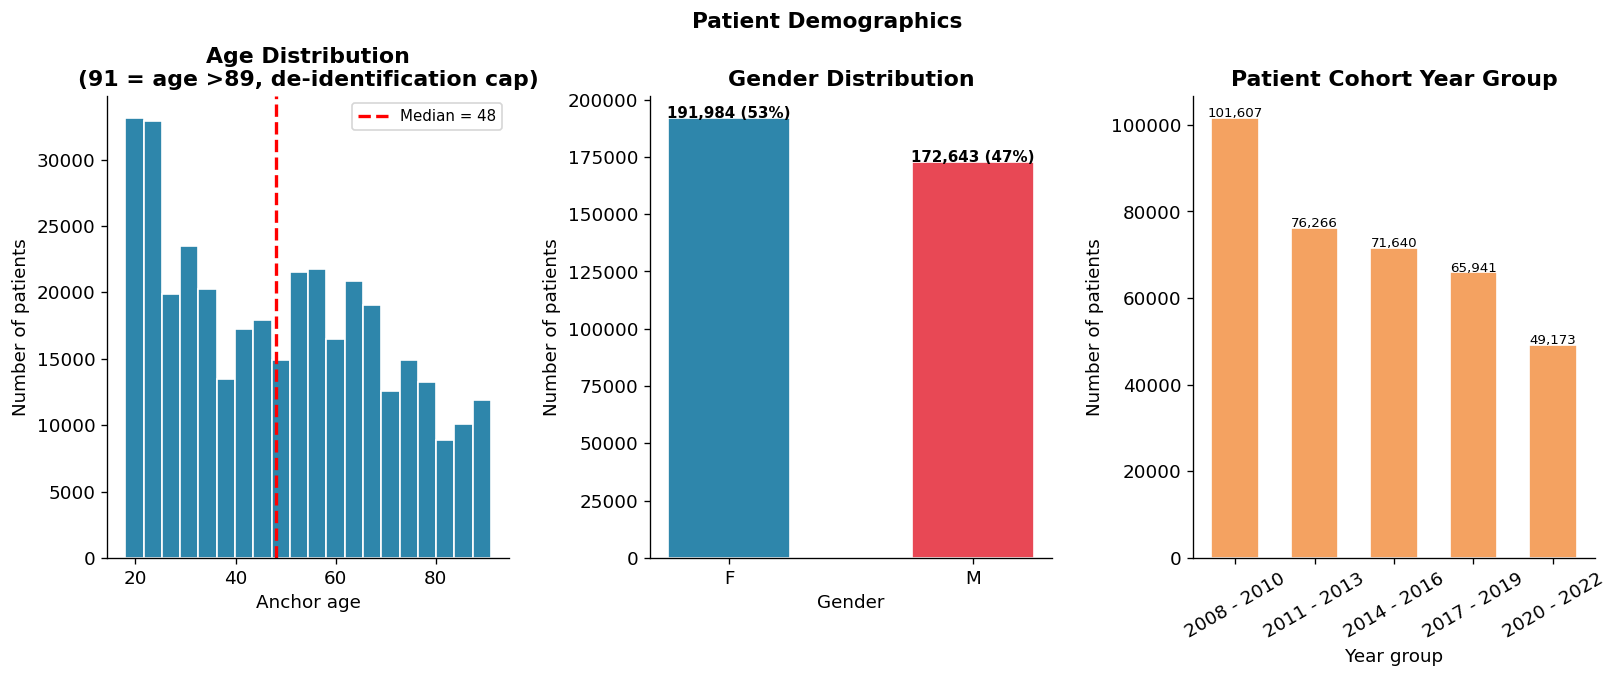

Total patients : 364,627
Age median (anchor) : 48
Patients age >89 : 8,445 (capped at 91)
Female / Male : 191,984 / 172,643
Known date of death : 38,301 (10.5%)


In [4]:
# Patient Demographic Characteristics
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(
    1,
    3,
    figure=fig,
    wspace=0.35
)

# Age Distribution
ax1 = fig.add_subplot(gs[0])

ax1.hist(
    patients['anchor_age'],
    bins=20,
    color=PALETTE[0],
    edgecolor='white'
)

median_age = patients['anchor_age'].median()

ax1.axvline(
    median_age,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {median_age:.0f}'
)

ax1.set_title(
    'Age Distribution\n(91 = age >89, de-identification cap)',
    fontweight='bold'
)

ax1.set_xlabel('Anchor age')
ax1.set_ylabel('Number of patients')
ax1.legend(fontsize=9)

# Gender Distribution
ax2 = fig.add_subplot(gs[1])

gender_counts = patients['gender'].value_counts()

bars = ax2.bar(
    gender_counts.index,
    gender_counts.values,
    color=[PALETTE[0], PALETTE[1]],
    edgecolor='white',
    width=0.5
)

for bar, value in zip(bars, gender_counts.values):

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{value:,} ({value / len(patients) * 100:.0f}%)',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title('Gender Distribution', fontweight='bold')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Number of patients')


# # Cohort Year Group Distribution
ax3 = fig.add_subplot(gs[2])

if 'anchor_year_group' in patients.columns:

    year_counts = (
        patients['anchor_year_group']
        .value_counts()
        .sort_index()
    )

    bars3 = ax3.bar(
        year_counts.index,
        year_counts.values,
        color=PALETTE[2],
        edgecolor='white',
        width=0.6
    )

    for bar, value in zip(bars3, year_counts.values):

        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{value:,}',
            ha='center',
            fontsize=8
        )

    ax3.tick_params(axis='x', rotation=30)

ax3.set_title(
    'Patient Cohort Year Group',
    fontweight='bold'
)

ax3.set_xlabel('Year group')
ax3.set_ylabel('Number of patients')

# Figure Formatting and Export
plt.suptitle(
    'Patient Demographics',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_01_patient_demographics.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics 
print(f'Total patients : {len(patients):,}')
print(f'Age median (anchor) : {median_age:.0f}')
print(f'Patients age >89 : {(patients["anchor_age"] == 91).sum():,} (capped at 91)')
print(f'Female / Male : {gender_counts.get("F", 0):,} / {gender_counts.get("M", 0):,}')

known_death = patients['dod'].notna()

print(
    f'Known date of death : {known_death.sum():,} '
    f'({known_death.mean() * 100:.1f}%)'
)

## Hospital Admissions Characteristics

Understanding patterns of hospital utilisation is essential for characterising patient complexity and healthcare resource demand within the study cohort. Figure 2 presents an overview of admission frequency, admission type distribution, and discharge destination across all recorded hospital encounters.

The number of admissions per patient is calculated to evaluate the prevalence of repeat hospitalisations, which may reflect chronic disease burden, multimorbidity, or complications requiring ongoing care. For visual clarity, extreme values are truncated at 20 admissions when displayed, while underlying calculations retain the full distribution.

Admission type categories are examined to identify the relative contribution of elective, emergency, and other admission pathways, providing insight into the acuity profile of the population. Similarly, discharge locations are analysed to assess patient outcomes following hospitalisation, including discharge to home, transfer to other healthcare facilities, or mortality-related destinations.

Together, these descriptive statistics provide a high-level overview of healthcare utilisation patterns within the dataset and establish context for subsequent analyses involving patient trajectories and clinical outcomes.

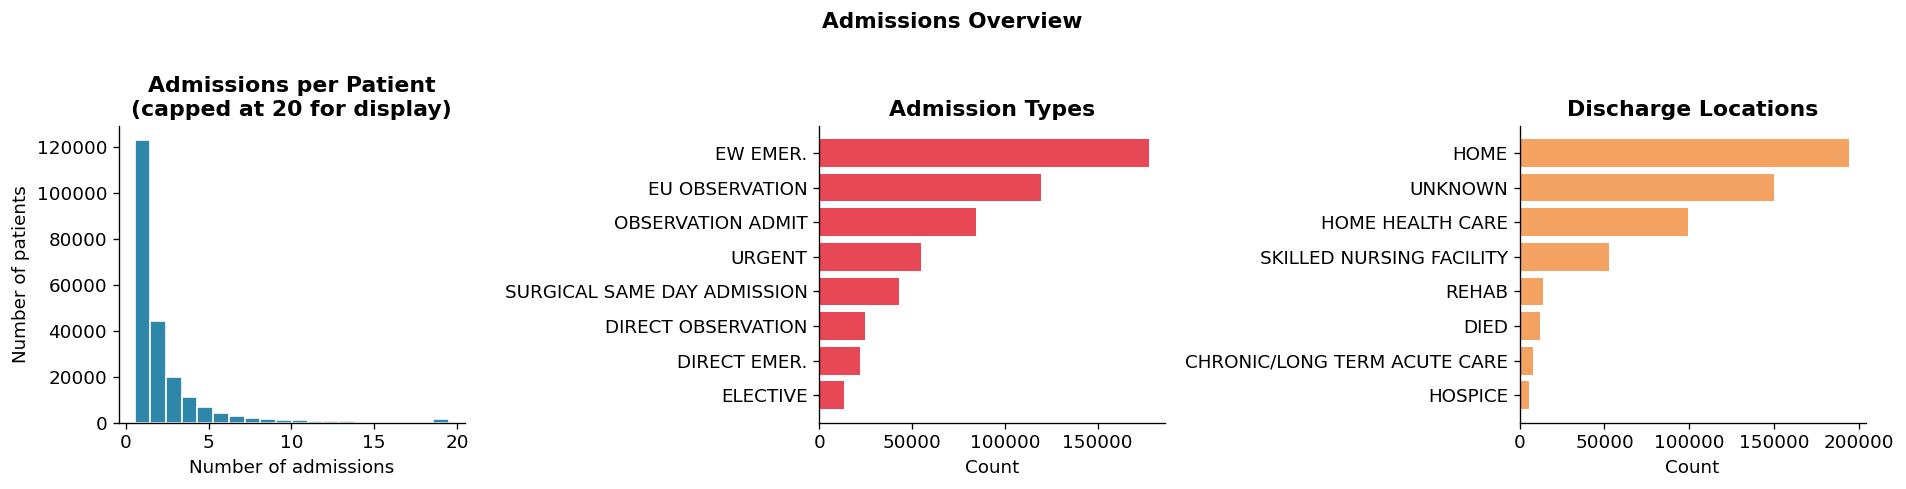

Total admissions : 546,028
Patients with >1 admission : 100,163 (44.8%)
Median admissions/patient : 1.0


In [5]:
# Hospital Admissions Overview

# Calculate Number of Admissions per Patient
adm_per_pt = admissions.groupby('subject_id').size()


fig, axes = plt.subplots(
      1,
      3,
      figsize=(16, 4)
)

# Admissions per Patient Distribution
axes[0].hist(
      adm_per_pt.clip(upper=20).values,
      bins=20,
      color=PALETTE[0],
      edgecolor='white',
      align='left'
)

axes[0].set_title(
      'Admissions per Patient\n(capped at 20 for display)',
      fontweight='bold'
)

axes[0].set_xlabel('Number of admissions')
axes[0].set_ylabel('Number of patients')

# Admission Type Distribution
adm_type = (
      admissions['admission_type']
      .value_counts()
      .head(8)
)

axes[1].barh(
      adm_type.index[::-1],
      adm_type.values[::-1],
      color=PALETTE[1]
)

axes[1].set_title('Admission Types', fontweight='bold')
axes[1].set_xlabel('Count')

# Discharge Location Distribution
disch = (
      admissions['discharge_location']
      .fillna('UNKNOWN')
      .value_counts()
      .head(8)
)

axes[2].barh(
      disch.index[::-1],
      disch.values[::-1],
      color=PALETTE[2]
)

axes[2].set_title('Discharge Locations', fontweight='bold')
axes[2].set_xlabel('Count')

# Figure Formatting and Export
plt.suptitle(
      'Admissions Overview',
      fontsize=13,
      fontweight='bold',
      y=1.01
)

plt.tight_layout()

plt.savefig(
      f'{EDA_PLT}/eda_02_admissions_overview.png',
      dpi=150,
      bbox_inches='tight'
)

plt.show()


# Summary Statistics 
multi_adm = adm_per_pt > 1

print(f'Total admissions : {len(admissions):,}')
print(
      f'Patients with >1 admission : {multi_adm.sum():,} '
      f'({multi_adm.mean() * 100:.1f}%)'
)
print(f'Median admissions/patient : {adm_per_pt.median():.1f}')

## Hospital Length of Stay Analysis

Length of hospital stay (LOS) is a clinically important indicator of disease severity, healthcare resource utilisation, and patient outcomes. Prolonged hospitalisation may reflect complications, comorbid conditions, or increased care requirements, whereas shorter stays may indicate less complex clinical presentations or efficient care pathways. Figure 3 examines the distribution of LOS across admissions and explores variation according to admission type.

To minimise the influence of extreme outliers and potential data entry anomalies, LOS values are truncated at 90 days for visualisation purposes, while summary statistics retain the underlying distributional characteristics. Both the mean and median LOS are displayed to provide complementary measures of central tendency, particularly given the expected right-skewed nature of hospital stay durations.

A stratified analysis by admission type is also presented using boxplots, allowing comparison of LOS distributions across different admission pathways. Observations exceeding 60 days are excluded from this comparison to improve interpretability of interquartile ranges and reduce distortion from extreme values. Admission categories are ordered according to median LOS to facilitate visual comparison between groups.

This analysis provides insight into hospital utilisation patterns and supports interpretation of subsequent outcome analyses involving patient trajectories and healthcare burden.

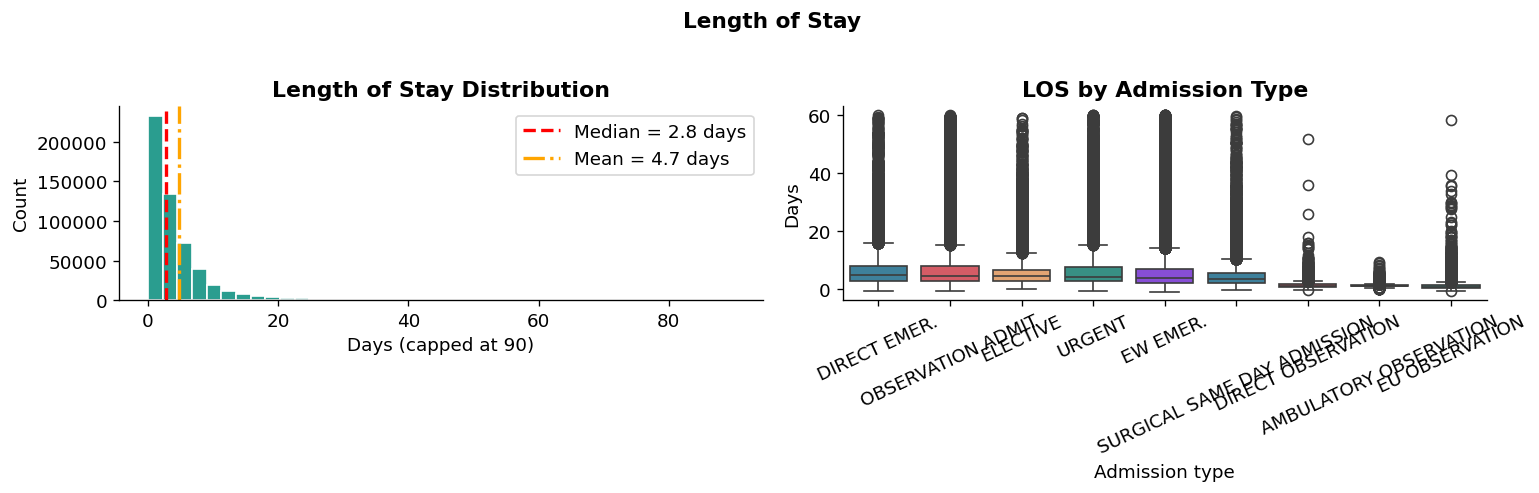

In [6]:
# Hospital Length of Stay (LOS)

# Clean LOS Values
los_clean = (
    admissions['los_days']
    .dropna()
    .clip(0, 90)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

# LOS Distribution
axes[0].hist(
    los_clean,
    bins=40,
    color=PALETTE[3],
    edgecolor='white'
)

median_los = los_clean.median()
mean_los   = los_clean.mean()

axes[0].axvline(
    median_los,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {median_los:.1f} days'
)

axes[0].axvline(
    mean_los,
    color='orange',
    linestyle='-.',
    lw=2,
    label=f'Mean = {mean_los:.1f} days'
)

axes[0].set_title('Length of Stay Distribution', fontweight='bold')
axes[0].set_xlabel('Days (capped at 90)')
axes[0].set_ylabel('Count')
axes[0].legend()

# LOS by Admission Type
los_type = (
    admissions[['admission_type', 'los_days']]
    .dropna()
)

los_type = los_type[
    los_type['los_days'] < 60
]

order = (
    los_type
    .groupby('admission_type')['los_days']
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=los_type,
    x='admission_type',
    y='los_days',
    order=order,
    ax=axes[1],
    palette=PALETTE
)

axes[1].set_title('LOS by Admission Type', fontweight='bold')
axes[1].set_xlabel('Admission type')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=25)

# Figure Formatting and Export
plt.suptitle(
    'Length of Stay',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_03_los_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Laboratory Measurement Coverage

Laboratory investigations constitute a central component of clinical assessment and monitoring, providing objective measures of physiological status and disease progression. Evaluating the frequency and distribution of laboratory measurements within the dataset is therefore important for understanding data completeness, potential feature availability, and variability in clinical monitoring intensity. Figure 5 summarises laboratory test utilisation across admissions.

The frequency of laboratory tests is first computed by aggregating measurement counts for each laboratory item identifier and linking these identifiers to descriptive labels using the laboratory reference table. The most frequently recorded laboratory tests are then visualised to identify commonly measured clinical parameters within the cohort.

In addition, the number of laboratory events per hospital admission is calculated to assess variability in testing intensity between encounters. Since some admissions involve extensive diagnostic evaluation, extreme values are truncated at 300 events for visualisation purposes to improve interpretability of the distribution. The median number of laboratory events per admission is displayed to provide a robust measure of central tendency.

This analysis provides insight into the breadth and density of laboratory data available for subsequent modelling or outcome analyses, and may also reflect differences in patient acuity or clinical complexity across admissions.

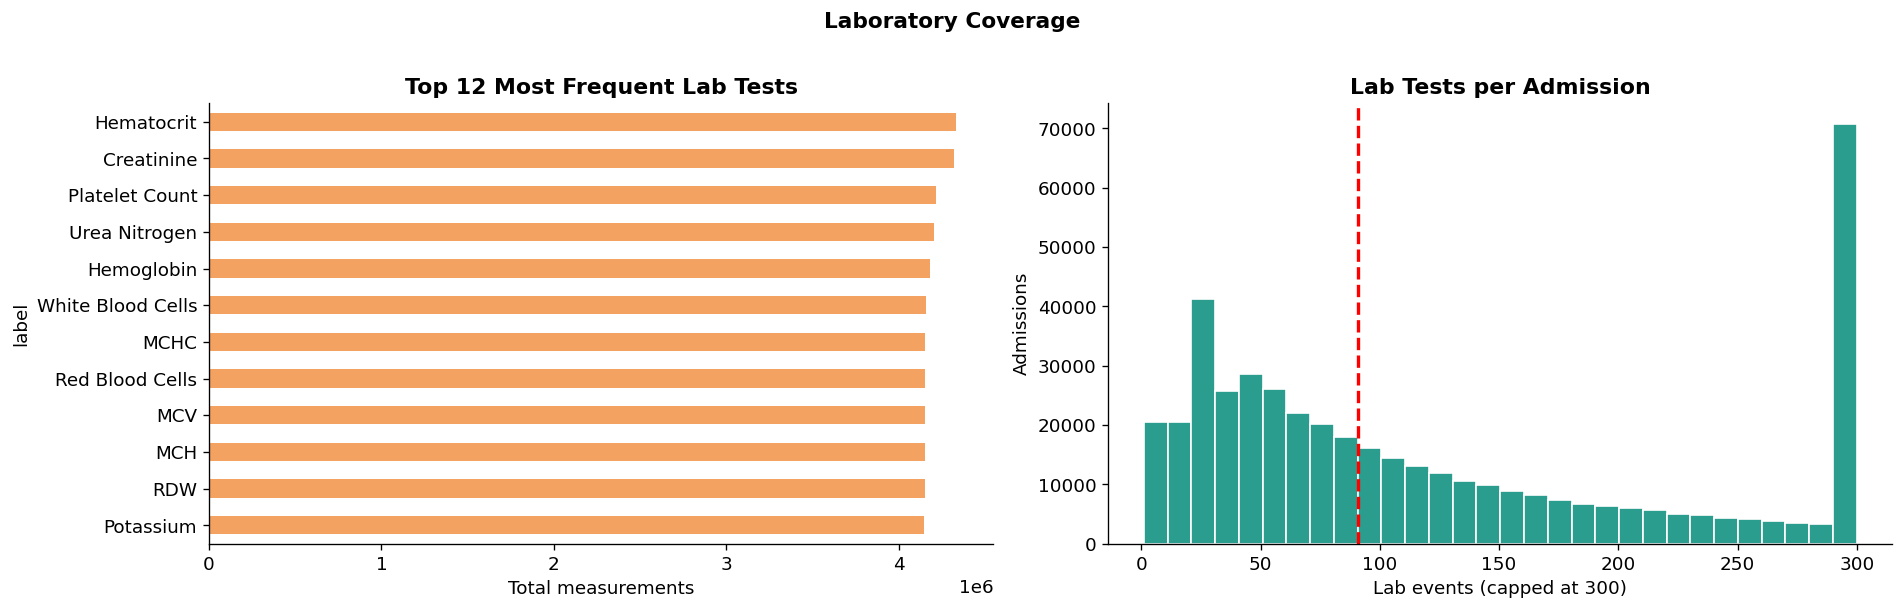

Total lab events : 158,374,764
Unique lab types : 976
Average lab events/admission : 189


In [7]:
# Laboratory Measurement Coverage

# Compute Frequency of Laboratory Tests by Item Identifier
lab_counts = (
    labevents
    .groupby('itemid')
    .size()
    .reset_index(name='count')
    .merge(
        d_labitems[['itemid', 'label']],
        on='itemid',
        how='left'
    )
    .sort_values('count', ascending=False)
)


# Number of Laboratory Events per Admission
labs_per_adm = (
    labevents
    .groupby('hadm_id')
    .size()
)

# Visualisations
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# Top Most Frequent Laboratory Tests
(
    lab_counts
    .set_index('label')['count']
    .head(12)
    .sort_values()
    .plot(
        kind='barh',
        ax=axes[0],
        color=PALETTE[2]
    )
)

axes[0].set_title(
    'Top 12 Most Frequent Lab Tests',
    fontweight='bold'
)

axes[0].set_xlabel('Total measurements')

# Laboratory Events per Admission Distribution
axes[1].hist(
    labs_per_adm.clip(0, 300),
    bins=30,
    color=PALETTE[3],
    edgecolor='white'
)

median_labs = labs_per_adm.median()

axes[1].axvline(
    median_labs,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {median_labs:.0f}'
)

axes[1].set_title('Lab Tests per Admission', fontweight='bold')
axes[1].set_xlabel('Lab events (capped at 300)')
axes[1].set_ylabel('Admissions')

# Figure Formatting and Export
plt.suptitle(
    'Laboratory Coverage',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_05_lab_coverage.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
print(f'Total lab events : {len(labevents):,}')
print(f'Unique lab types : {labevents["itemid"].nunique()}')
print(f'Average lab events/admission : {labs_per_adm.mean():.0f}')

## Diagnostic Code Distribution and Clinical Categories

Diagnostic coding provides a structured representation of patient conditions and is fundamental for understanding disease burden within the study population. Figure 4 presents an analysis of diagnosis frequency using International Classification of Diseases (ICD) codes, including both individual diagnostic labels and broader clinical groupings.

To enhance interpretability, diagnostic codes are first mapped to their corresponding descriptive titles using the ICD reference table. Where descriptive labels are unavailable, the original code is retained to preserve information completeness. In addition, ICD-10 codes are categorised into higher-level clinical chapters based on their leading character, enabling aggregation into clinically meaningful disease domains such as circulatory, respiratory, and endocrine conditions. ICD-9 codes are retained as a separate category due to differences in classification structure.

The most frequently recorded diagnoses are visualised to identify common clinical conditions represented in the dataset. A complementary analysis summarises diagnoses by ICD chapter to provide a broader overview of disease category prevalence within the cohort.

This analysis supports understanding of the clinical composition of the population and informs feature selection for subsequent modelling or outcome analyses by highlighting prevalent diagnostic patterns.

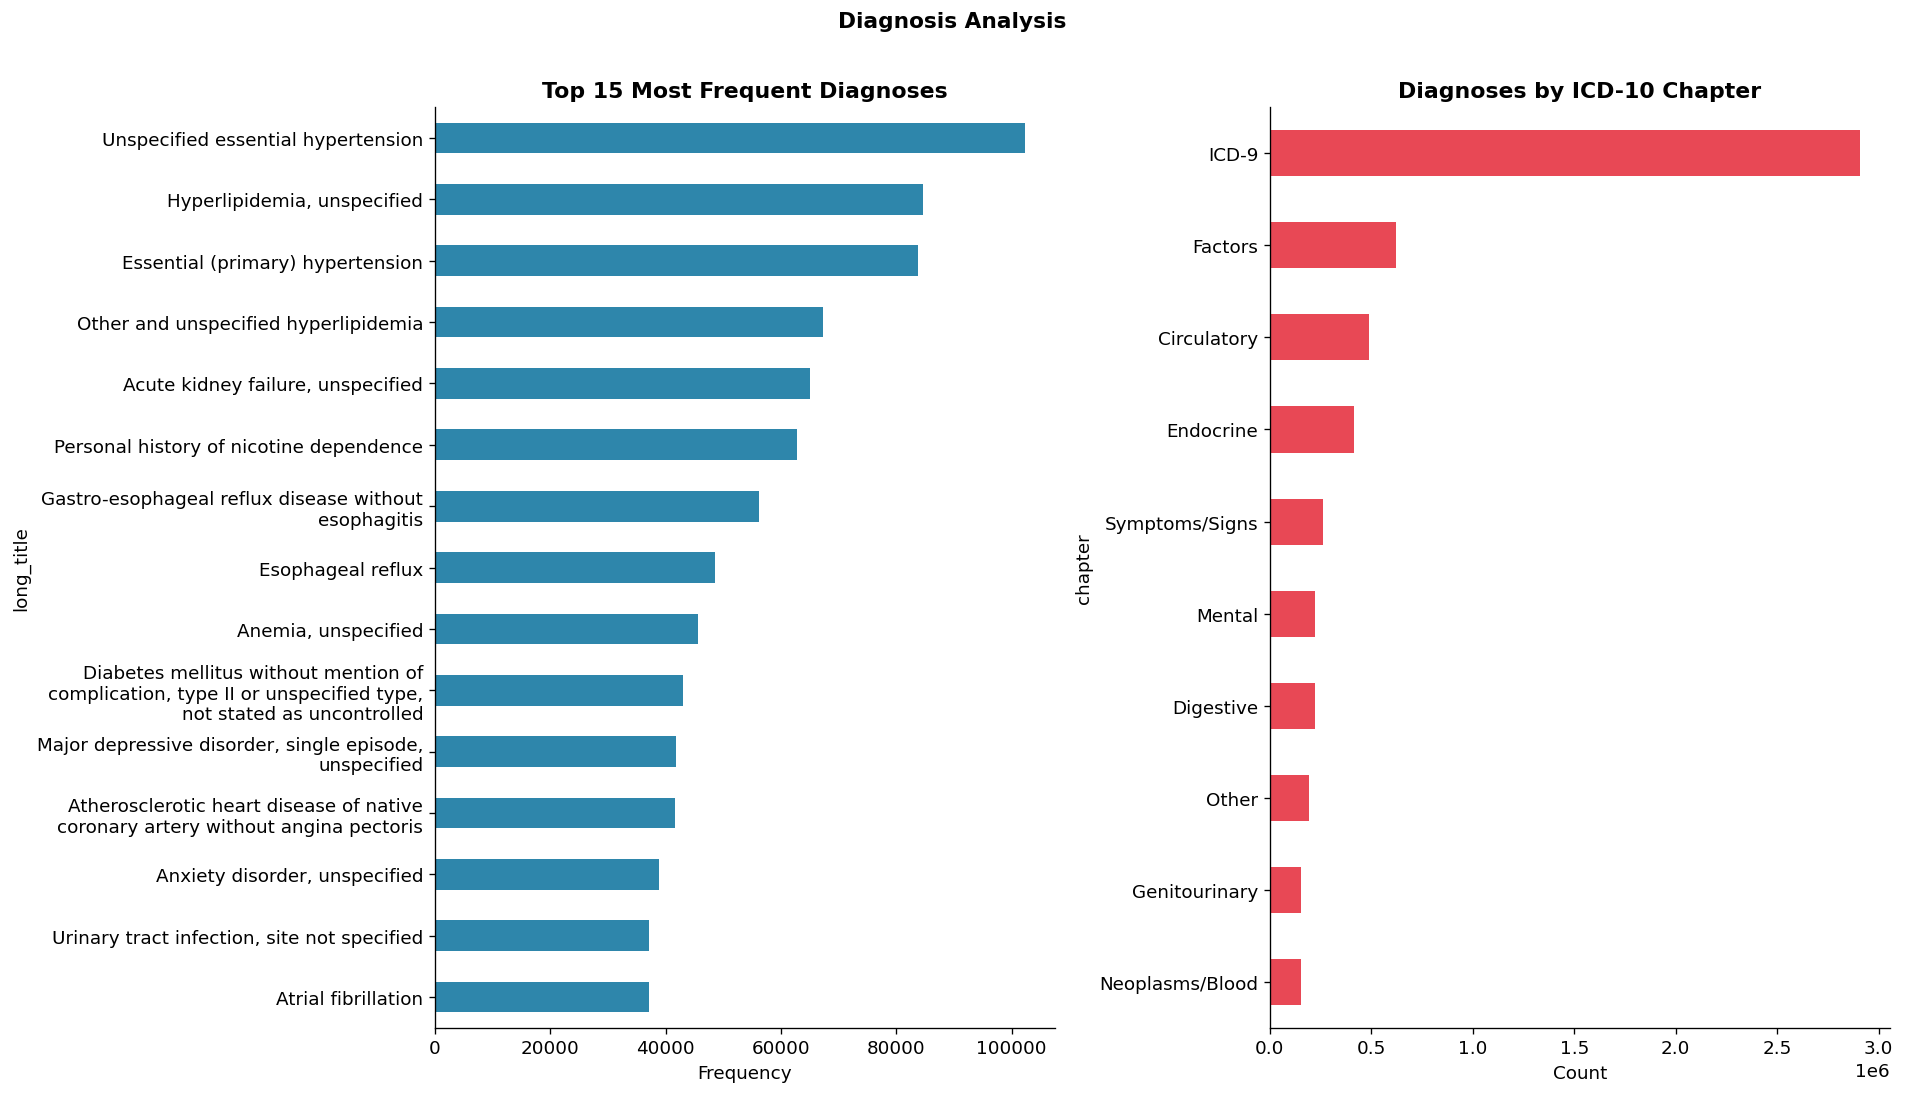

Total diagnosis records : 6,364,488
Unique ICD codes : 28,562
Avg diagnoses/admission : 11.7


In [8]:
# Diagnostic Chapter Mapping Function
def icd_chapter(code, version):

    code = str(code).strip().upper()

    if version == 10:

        chapters = {
            'A': 'Infectious',
            'B': 'Infectious',
            'C': 'Neoplasms',
            'D': 'Neoplasms/Blood',
            'E': 'Endocrine',
            'F': 'Mental',
            'G': 'Nervous',
            'H': 'Eye/Ear',
            'I': 'Circulatory',
            'J': 'Respiratory',
            'K': 'Digestive',
            'L': 'Skin',
            'M': 'Musculoskeletal',
            'N': 'Genitourinary',
            'R': 'Symptoms/Signs',
            'S': 'Injury',
            'T': 'Injury',
            'Z': 'Factors'
        }

        return chapters.get(
            code[0] if code else 'X',
            'Other'
        )

    return 'ICD-9'

# Merge Diagnosis Codes with Descriptive Labels
diagnoses_named = diagnoses.merge(
    d_icd_diag[['icd_code', 'icd_version', 'long_title']],
    on=['icd_code', 'icd_version'],
    how='left'
)

diagnoses_named['long_title'] = diagnoses_named['long_title'].fillna(
    diagnoses_named['icd_code']
)


# Assign ICD Chapter Categories
diagnoses_named['chapter'] = diagnoses_named.apply(
    lambda row: icd_chapter(
        row['icd_code'],
        row['icd_version']
    ),
    axis=1
)

# Frequency Calculations
top15 = (
    diagnoses_named['long_title']
    .value_counts()
    .head(15)
)

chapter_counts = (
    diagnoses_named['chapter']
    .value_counts()
)

# Visualisations
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 9)
)


# Wrap Long Diagnostic Labels for Improved Readability
wrapped_labels = [
    textwrap.fill(label, width=45)
    for label in top15[::-1].index
]


# Top Diagnoses Plot
top15[::-1].plot(
    kind='barh',
    ax=axes[0],
    color=PALETTE[0]
)

axes[0].set_title(
    'Top 15 Most Frequent Diagnoses',
    fontweight='bold'
)

axes[0].set_yticklabels(wrapped_labels)
axes[0].set_xlabel('Frequency')


# ICD Chapter Distribution Plot
(
    chapter_counts
    .head(10)
    .sort_values()
    .plot(
        kind='barh',
        ax=axes[1],
        color=PALETTE[1]
    )
)

axes[1].set_title(
    'Diagnoses by ICD-10 Chapter',
    fontweight='bold'
)

axes[1].set_xlabel('Count')

# Figure Formatting and Export
plt.suptitle(
    'Diagnosis Analysis',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_04_top_diagnoses.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics
diagnoses_per_adm = diagnoses.groupby('hadm_id').size()

print(f'Total diagnosis records : {len(diagnoses):,}')
print(f'Unique ICD codes : {diagnoses["icd_code"].nunique():,}')
print(f'Avg diagnoses/admission : {diagnoses_per_adm.mean():.1f}')

## Laboratory Data Availability and Measurement Intensity

Laboratory measurements represent a critical source of objective clinical information and are frequently used for both descriptive analyses and predictive modelling in healthcare research. Assessing the availability and distribution of laboratory data within the dataset is therefore important for understanding data completeness and variability in clinical monitoring practices. Figure 5 provides an overview of laboratory test frequency and measurement intensity across hospital admissions.

Laboratory item identifiers are first linked to their descriptive labels using the laboratory metadata reference table to enable interpretation of test types. The most frequently recorded laboratory investigations are then identified to highlight commonly measured physiological and biochemical parameters within the cohort.

In addition, the number of laboratory events per admission is calculated to evaluate variability in testing intensity between hospital encounters. Since some admissions involve extensive diagnostic workups, extreme values are truncated at 500 measurements for visualisation purposes to improve interpretability while preserving the underlying distribution for statistical summaries. The median number of laboratory events per admission is displayed as a robust indicator of central tendency.

This analysis provides insight into the density and breadth of laboratory information available within the dataset and may also reflect differences in patient acuity, clinical complexity, and monitoring requirements across admissions.

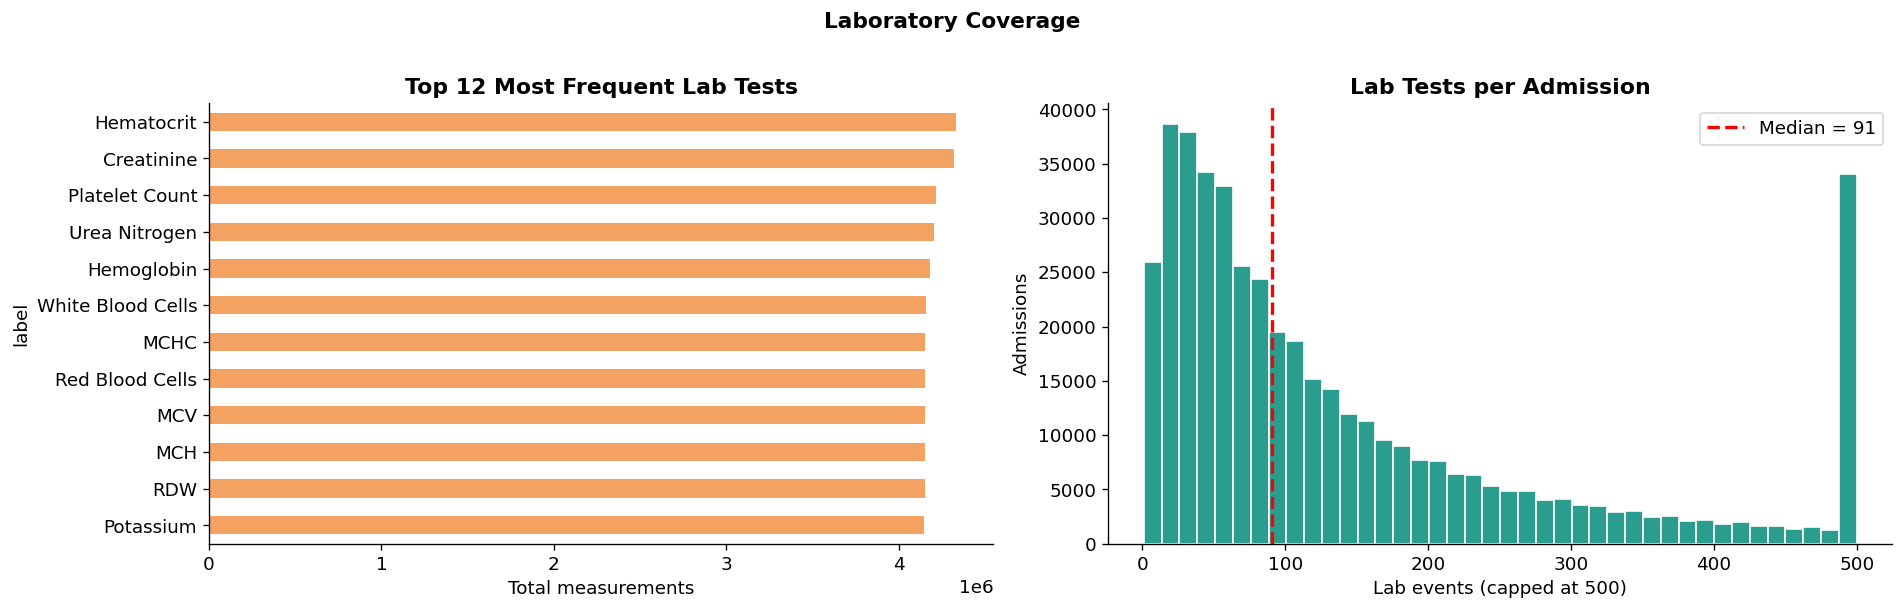

Total lab events : 158,374,764
Unique lab item types : 976
Avg lab events/admission : 189


In [9]:
# Laboratory Coverage (MIMIC-IV v3.1)

# Laboratory Metadata Subset
lab_cols = ['itemid', 'label']
lab_meta = d_labitems[lab_cols].copy()

# Laboratory Test Frequency Calculation
lab_counts = (
    labevents
    .groupby('itemid')
    .size()
    .reset_index(name='count')
    .merge(
        lab_meta,
        on='itemid',
        how='left'
    )
    .sort_values('count', ascending=False)
)


# Number of Laboratory Events per Admission
labs_per_adm = (
    labevents
    .groupby('hadm_id')
    .size()
)

# Visualisations
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)


# Top Most Frequent Laboratory Tests
(
    lab_counts
    .set_index('label')['count']
    .head(12)
    .sort_values()
    .plot(
        kind='barh',
        ax=axes[0],
        color=PALETTE[2]
    )
)

axes[0].set_title(
    'Top 12 Most Frequent Lab Tests',
    fontweight='bold'
)

axes[0].set_xlabel('Total measurements')

# Laboratory Events per Admission Distribution
axes[1].hist(
    labs_per_adm.clip(upper=500),
    bins=40,
    color=PALETTE[3],
    edgecolor='white'
)

median_labs = labs_per_adm.median()

axes[1].axvline(
    median_labs,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Median = {median_labs:.0f}'
)

axes[1].set_title('Lab Tests per Admission', fontweight='bold')
axes[1].set_xlabel('Lab events (capped at 500)')
axes[1].set_ylabel('Admissions')
axes[1].legend()

# Figure Formatting and Export
plt.suptitle(
    'Laboratory Coverage',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_05_lab_coverage.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics 
print(f'Total lab events : {len(labevents):,}')
print(f'Unique lab item types : {labevents["itemid"].nunique():,}')
print(f'Avg lab events/admission : {labs_per_adm.mean():.0f}')

## Intensive Care Unit (ICU) Utilisation

Intensive care unit (ICU) admissions represent a key indicator of patient acuity and healthcare resource utilisation, reflecting cases requiring advanced monitoring or life-support interventions. Analysing ICU utilisation patterns provides insight into disease severity within the cohort and supports interpretation of downstream outcome analyses. Figure 6 summarises ICU length of stay, the proportion of hospital admissions involving ICU care, and the frequency of ICU admissions per patient.

Hospital admissions are first linked to ICU records by identifying admissions associated with at least one ICU stay. This binary indicator enables estimation of the proportion of hospital encounters requiring critical care services. ICU length of stay is examined to assess the duration of intensive treatment, with extreme values truncated at 30 days for visualisation clarity while preserving the overall distributional characteristics.

In addition, the number of ICU admissions per patient is calculated to evaluate repeat critical care utilisation. Values are capped at 10 ICU stays for display purposes to improve interpretability of the distribution. Together, these analyses provide a comprehensive overview of ICU utilisation patterns and highlight the burden of critical illness within the study population.

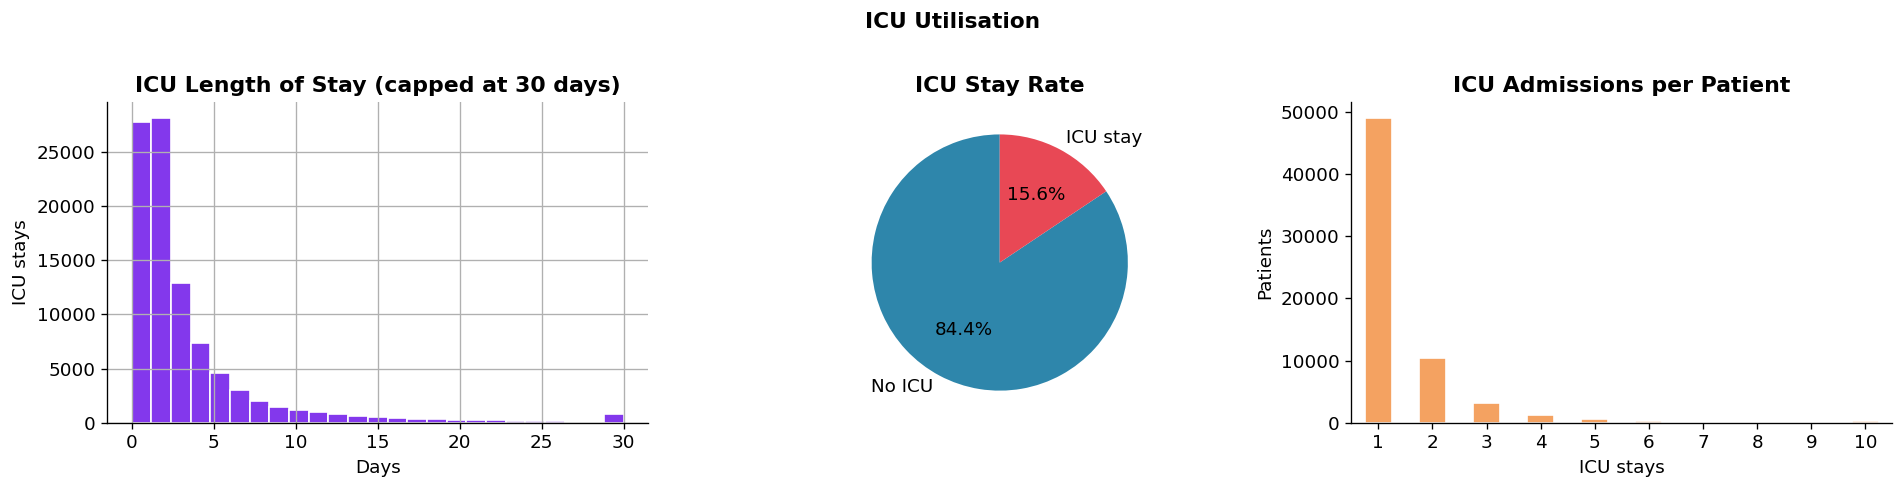

Admissions with ICU : 85,242 (15.6%)


In [10]:
# ICU Utilisation

# Identify Admissions Associated with ICU Stays
icu_hadm = set(
    icustays['hadm_id'].unique()
)

admissions['had_icu'] = (
    admissions['hadm_id']
    .isin(icu_hadm)
    .astype(int)
)


# ICU Admissions per Patient
icu_per_pt = (
    icustays
    .groupby('subject_id')
    .size()
)


# Visualisation
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

# ICU Length of Stay Distribution
icustays['los'].clip(upper=30).hist(
    bins=25,
    ax=axes[0],
    color=PALETTE[4],
    edgecolor='white'
)

axes[0].set_title(
    'ICU Length of Stay (capped at 30 days)',
    fontweight='bold'
)

axes[0].set_xlabel('Days')
axes[0].set_ylabel('ICU stays')

# Proportion of Admissions with ICU Stay
icu_prop = admissions['had_icu'].value_counts()

axes[1].pie(
    icu_prop.values,
    labels=['No ICU', 'ICU stay'],
    colors=[PALETTE[0], PALETTE[1]],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

axes[1].set_title(
    'ICU Stay Rate',
    fontweight='bold'
)

# ICU Admissions per Patient Distribution
(
    icu_per_pt
    .clip(upper=10)
    .value_counts()
    .sort_index()
    .plot(
        kind='bar',
        ax=axes[2],
        color=PALETTE[2],
        edgecolor='white'
    )
)

axes[2].set_title(
    'ICU Admissions per Patient',
    fontweight='bold'
)

axes[2].set_xlabel('ICU stays')
axes[2].set_ylabel('Patients')
axes[2].tick_params(axis='x', rotation=0)

# Figure Formatting and Export
plt.suptitle(
    'ICU Utilisation',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_06_icu_utilisation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics 
icu_admissions = admissions['had_icu']

print(
    f'Admissions with ICU : {icu_admissions.sum():,} '
    f'({icu_admissions.mean() * 100:.1f}%)'
)

## Temporal Distribution of Hospital Admissions

Examining the temporal distribution of hospital admissions provides insight into dataset coverage, potential seasonal patterns, and changes in healthcare utilisation over time. Figure 7 presents the distribution of admissions by de-identified calendar year and month.

Due to privacy-preserving de-identification procedures applied within the MIMIC-IV dataset, actual calendar years are shifted while preserving temporal relationships between events. Consequently, the reported admission years represent relative rather than absolute chronological time. Admissions occurring in later de-identified years correspond approximately to the 2020–2022 period included in version 3.x of the dataset.

Monthly admission patterns are also analysed to explore potential seasonal variation in hospital utilisation. Understanding temporal coverage is important for contextualising analyses, particularly when investigating trends, cohort shifts, or external influences such as healthcare system pressures.

This temporal overview confirms the longitudinal scope of the dataset and supports interpretation of subsequent analyses involving patient trajectories and outcomes.

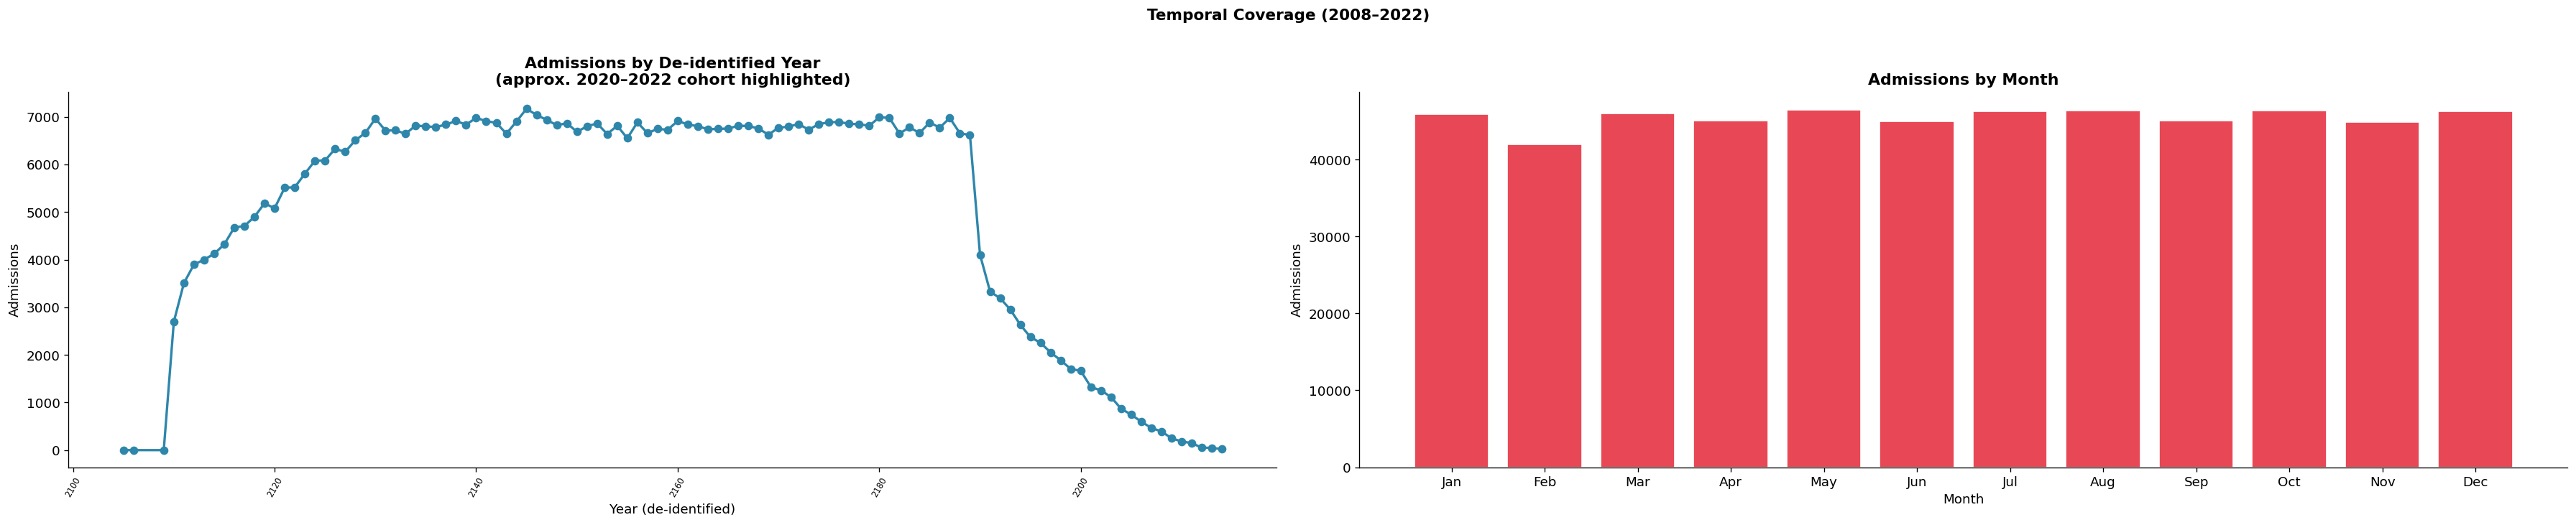

In [11]:
# Temporal Coverage of Admissions

# Extract Temporal Components from Admission Timestamp
admissions['admit_year'] = admissions['admittime'].dt.year
admissions['admit_month'] = admissions['admittime'].dt.month


fig, axes = plt.subplots(
    1,
    2,
    figsize=(30, 6)
)

# Admissions by De-identified Year
year_counts = (
    admissions['admit_year']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

axes[0].plot(
    year_counts.index,
    year_counts.values,
    marker='o',
    linewidth=2,
    color=PALETTE[0]
)

axes[0].set_title(
    'Admissions by De-identified Year\n(approx. 2020–2022 cohort highlighted)',
    fontweight='bold'
)

axes[0].set_xlabel('Year (de-identified)')
axes[0].set_ylabel('Admissions')
axes[0].tick_params(axis='x', rotation=60, labelsize=7)

# Admissions by Month
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

month_counts = (
    admissions['admit_month']
    .value_counts()
    .sort_index()
)

axes[1].bar(
    month_names,
    [month_counts.get(i, 0) for i in range(1, 13)],
    color=PALETTE[1],
    edgecolor='white'
)

axes[1].set_title('Admissions by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Admissions')

# Figure Formatting and Export
plt.suptitle(
    'Temporal Coverage (2008–2022)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_07_temporal_coverage.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Comorbidity Co-occurrence Analysis

Comorbidity patterns provide important insight into the clinical complexity of patients and the relationships between frequently co-existing conditions. Analysing co-occurrence of diagnoses can help identify common disease clusters, multimorbidity profiles, and potential interactions between clinical conditions. Figure 8 presents a heatmap illustrating co-occurrence frequencies among the most prevalent diagnoses within the dataset.

The analysis focuses on the twelve most frequently recorded diagnostic categories, identified using descriptive diagnosis titles. A binary presence matrix is constructed at the hospital admission level, indicating whether each diagnosis occurs within a given admission. This representation enables computation of pairwise co-occurrence counts through matrix multiplication, producing a symmetric matrix that quantifies how often diagnoses appear together across admissions.

To improve interpretability, diagonal values representing self-occurrence are removed, ensuring that the heatmap emphasises relationships between distinct conditions rather than marginal frequencies. The resulting visualisation highlights common comorbidity patterns and provides insight into the clinical structure of the patient population.

Understanding these relationships is particularly valuable for downstream modelling tasks, risk stratification analyses, and identification of clinically meaningful patient subgroups.

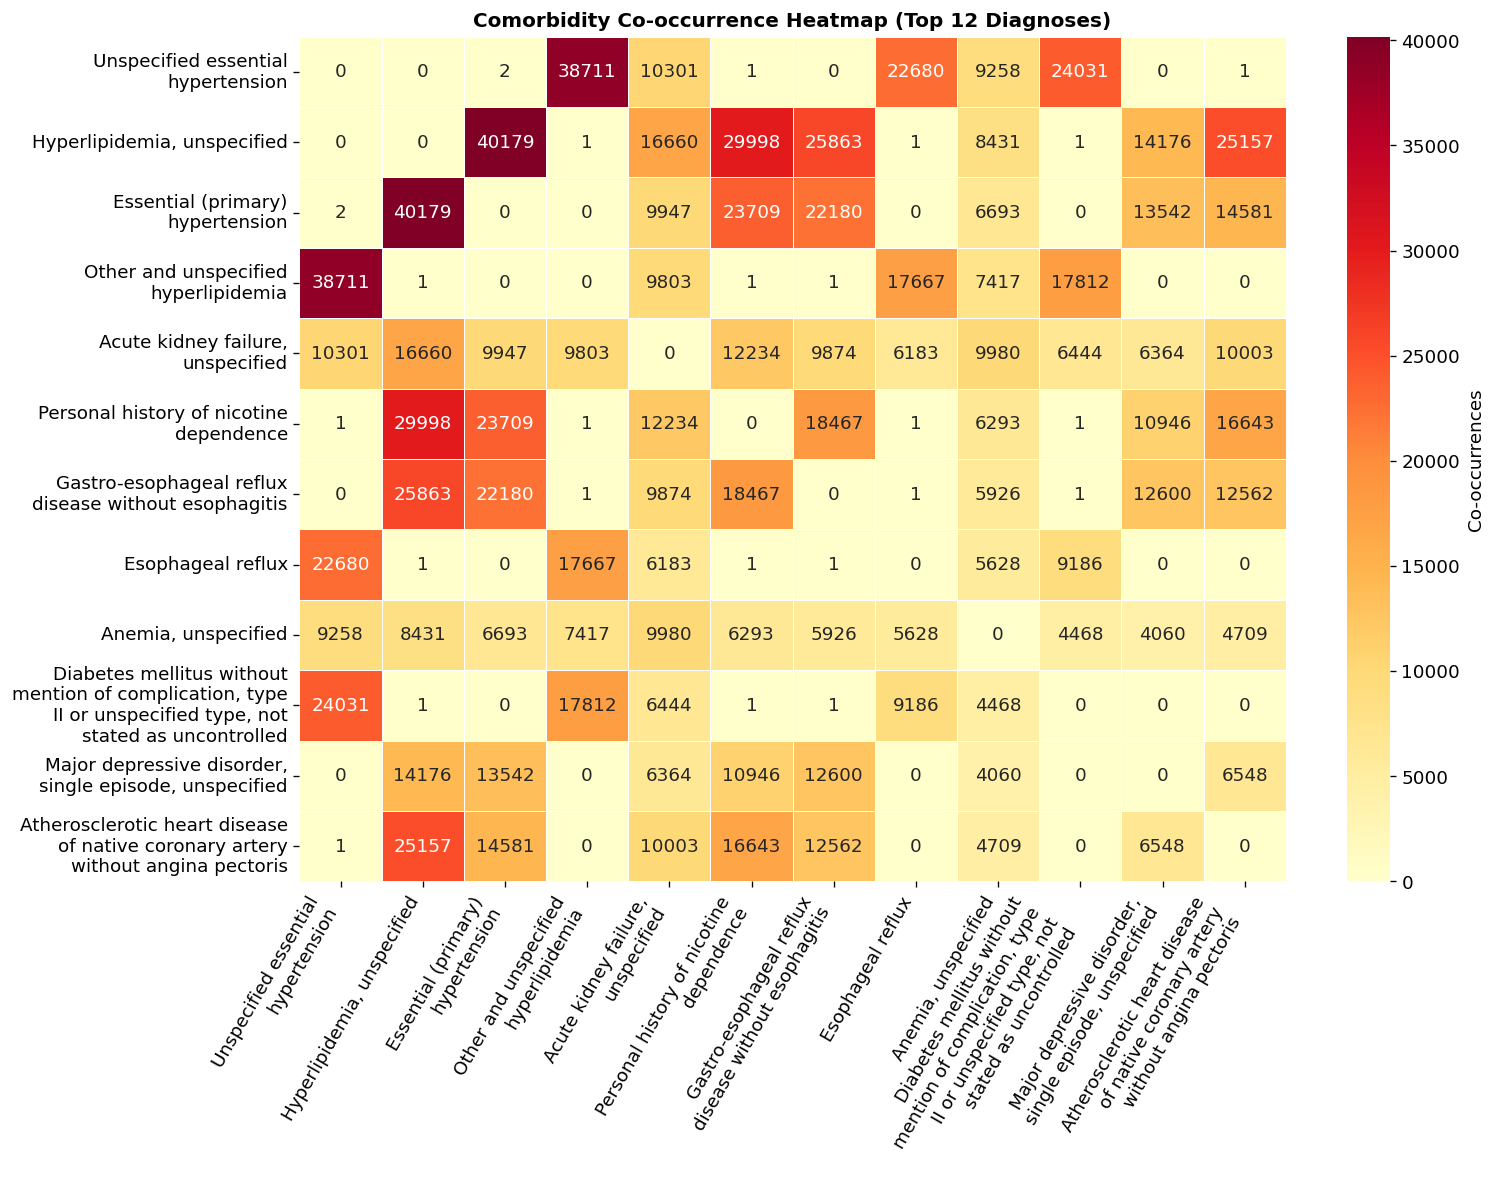

In [12]:
# Comorbidity Co-occurrence Heatmap

# Identify Most Frequent Diagnoses
top12_titles = (
    diagnoses_named['long_title']
    .value_counts()
    .head(12)
    .index
    .tolist()
)


# Set of Valid Hospital Admissions
hadm_set = set(
    admissions['hadm_id'].tolist()
)

# Construct Diagnosis Presence Matrix (Admission-Level)
presence = pd.DataFrame(
    0,
    index=list(hadm_set),
    columns=top12_titles
)

for title in top12_titles:
    hadm_ids = (
        diagnoses_named[
            diagnoses_named['long_title'] == title
        ]['hadm_id']
        .unique()
    )

    valid_ids = [
        h for h in hadm_ids
        if h in hadm_set
    ]

    presence.loc[valid_ids, title] = 1

# Compute Co-occurrence Matrix
cooccur = presence.T.dot(presence)


# Remove Diagonal Values (Self-Co-occurrence)
cooccur_array = cooccur.to_numpy().copy()
np.fill_diagonal(cooccur_array, 0)

cooccur = pd.DataFrame(
    cooccur_array,
    index=cooccur.index,
    columns=cooccur.columns
)

# Visualisation: Heatmap
wrapped_labels = [
    textwrap.fill(label, width=30)
    for label in cooccur.columns
]

fig, ax = plt.subplots(
    figsize=(13, 10)
)

sns.heatmap(
    cooccur,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Co-occurrences'}
)

# Wrapped Labels
ax.set_xticklabels(wrapped_labels, rotation=60, ha='right')
ax.set_yticklabels(wrapped_labels, rotation=0)

ax.set_title(
    'Comorbidity Co-occurrence Heatmap (Top 12 Diagnoses)',
    fontsize=12,
    fontweight='bold'
)

# Figure Formatting and Export
plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_08_comorbidity_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Anthropometric Measurements from the OMR Table

The Online Medical Record (OMR) table, introduced in later versions of the MIMIC-IV dataset, provides additional patient-level physiological and anthropometric measurements that complement traditional hospital event data. These measurements include variables such as body mass index (BMI), weight, and height, which are important indicators of patient health status and may contribute to risk stratification and outcome prediction. Figure 9 summarises the distribution of these anthropometric variables within the dataset.

To identify relevant measurements, OMR records are filtered according to the `result_name` field using keyword matching for BMI, weight, and height. Numerical conversion is applied to measurement values to ensure compatibility with statistical analysis, with invalid entries coerced to missing values. Extreme values are truncated within clinically plausible ranges for visualisation purposes to reduce the influence of potential measurement errors or unit inconsistencies.

The resulting distributions provide insight into the availability and variability of anthropometric data across patients. Since these measurements are not uniformly recorded for all individuals, understanding their coverage is important when considering their inclusion in downstream analyses or predictive modelling tasks.

OMR result_name values:
result_name
Blood Pressure                      2827801
Weight (Lbs)                        2145353
BMI (kg/m2)                         1901496
Height (Inches)                      814964
BMI                                   29021
Weight                                15108
Blood Pressure Sitting                 5757
Blood Pressure Standing (1 min)        4704
Blood Pressure Lying                   4359
Height                                 2365
Blood Pressure Standing (3 mins)       1255
Blood Pressure Standing                 565
eGFR                                    279


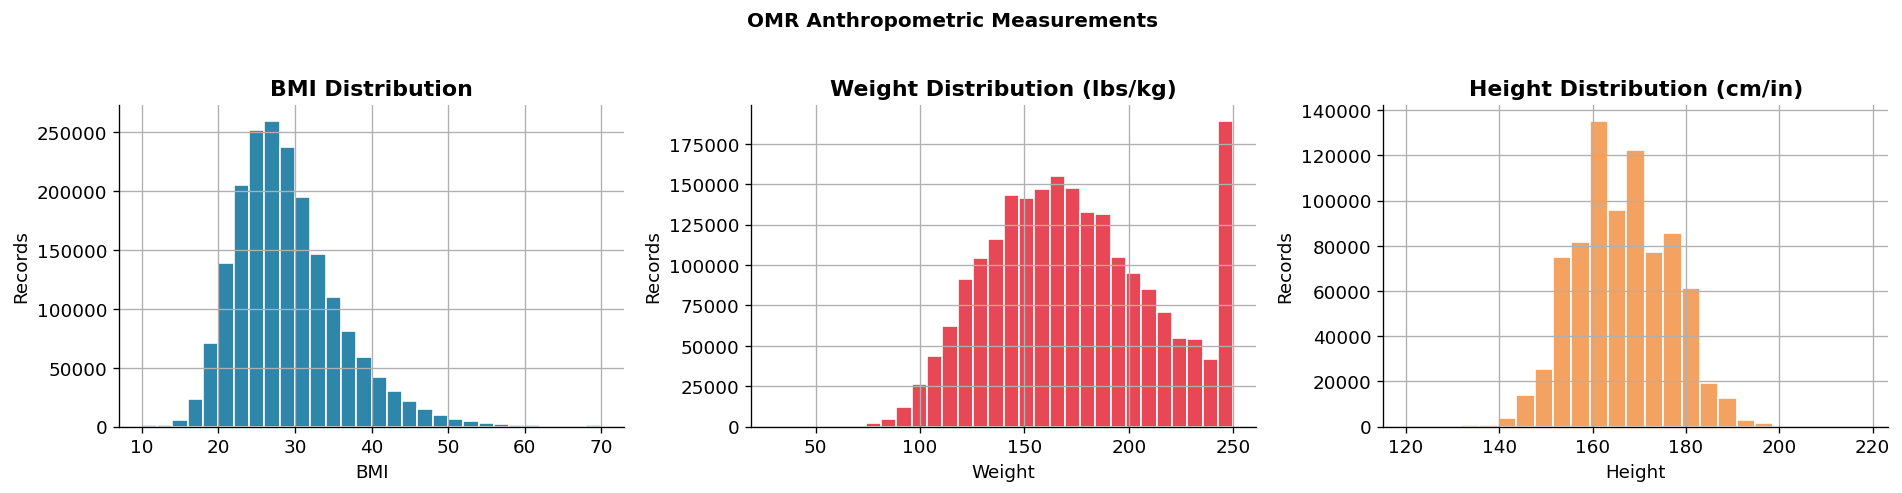


OMR records total : 7,753,027
BMI records : 1,930,517
Weight records : 2,160,461
Height records : 816,615
Unique patients : 193,501


In [13]:
# Anthropometric Measurements from OMR Table

# Inspect Most Common OMR Measurement Types
print('OMR result_name values:')
print(
    omr['result_name']
    .value_counts()
    .head(15)
    .to_string()
)

# Filter Anthropometric Measurements
omr_bmi = omr[
    omr['result_name']
    .str.lower()
    .str.contains('bmi', na=False)
].copy()

omr_weight = omr[
    omr['result_name']
    .str.lower()
    .str.contains('weight', na=False)
].copy()

omr_height = omr[
    omr['result_name']
    .str.lower()
    .str.contains('height', na=False)
].copy()


# Convert Measurement Values to Numeric
for df in [omr_bmi, omr_weight, omr_height]:

    df['result_value'] = pd.to_numeric(
        df['result_value'],
        errors='coerce'
    )

# Visualisations
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)


# BMI Distribution
omr_bmi['result_value'].dropna().clip(10, 70).hist(
    bins=30,
    ax=axes[0],
    color=PALETTE[0],
    edgecolor='white'
)

axes[0].set_title('BMI Distribution', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Records')


# Weight Distribution
omr_weight['result_value'].dropna().clip(30, 250).hist(
    bins=30,
    ax=axes[1],
    color=PALETTE[1],
    edgecolor='white'
)

axes[1].set_title('Weight Distribution (lbs/kg)', fontweight='bold')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Records')


# Height Distribution
omr_height['result_value'] = omr_height['result_value'] * 2.54

# Remove unrealistic adult height values
omr_height = omr_height[
    (omr_height['result_value'] >= 120) &
    (omr_height['result_value'] <= 220)
]

omr_height['result_value'].dropna().hist(
    bins=25,
    ax=axes[2],
    color=PALETTE[2],
    edgecolor='white'
)

axes[2].set_title('Height Distribution (cm/in)', fontweight='bold')
axes[2].set_xlabel('Height')
axes[2].set_ylabel('Records')

# Figure Formatting and Export
plt.suptitle(
    'OMR Anthropometric Measurements',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_09_omr_vitals.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary Statistics 
print(f'\nOMR records total : {len(omr):,}')
print(f'BMI records : {len(omr_bmi):,}')
print(f'Weight records : {len(omr_weight):,}')
print(f'Height records : {len(omr_height):,}')
print(f'Unique patients : {omr["subject_id"].nunique():,}')

## Mortality Data Overview

Mortality outcomes are a critical endpoint in clinical research and are essential for evaluating patient prognosis, healthcare quality, and disease severity. The MIMIC-IV dataset captures mortality information through multiple mechanisms, including in-hospital death indicators and linkage to external death records (e.g., state-level registries). Figure 10 provides an overview of mortality data availability within the cohort.

The first visualisation summarises the number of patients with a recorded date of death, those identified as having died during hospital admission, and those without documented mortality information. Distinguishing between these categories is important because external death linkage enables identification of deaths occurring outside the hospital setting, thereby improving outcome completeness compared with relying solely on in-hospital mortality indicators.

The second visualisation examines the age distribution of patients with a known date of death, using the anchor age variable as an approximate measure of age at the reference time point. Due to de-identification procedures within MIMIC-IV, ages above 89 years are top-coded at 91, which should be considered when interpreting distributions involving older patients.

This analysis provides insight into mortality data coverage and supports interpretation of subsequent outcome analyses involving survival, risk prediction, or healthcare utilisation patterns.

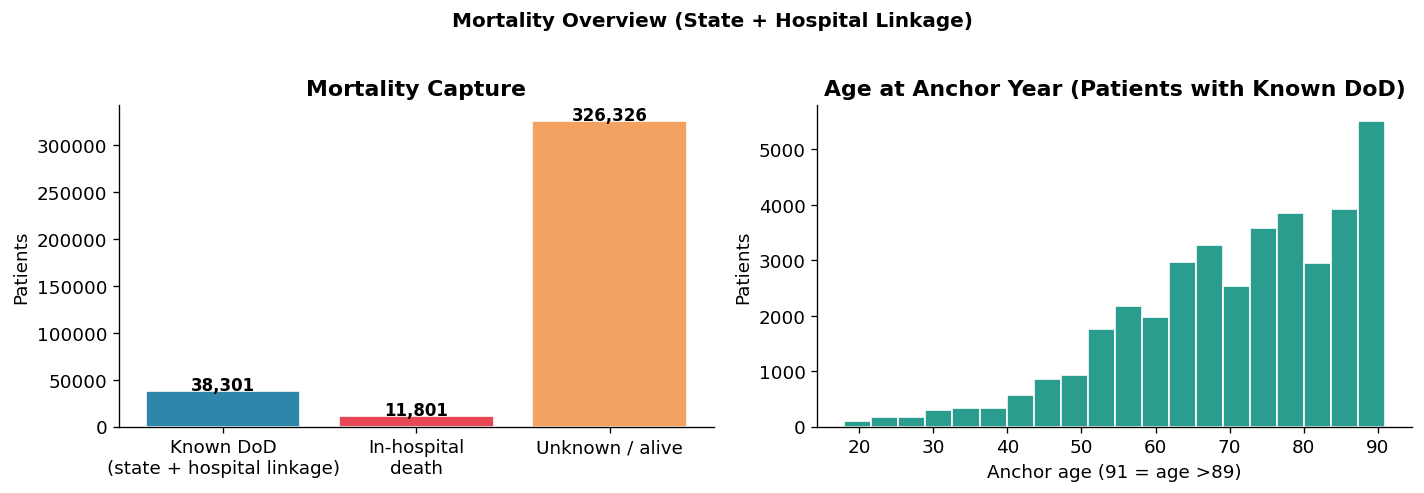

In [14]:
# Mortality Overview

# In-Hospital Mortality Count
in_hosp_death = (
    admissions['hospital_expire_flag'].sum()
    if 'hospital_expire_flag' in admissions.columns
    else 0
)

# Patients with Known Date of Death
known_dod = patients['dod'].notna().sum()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Mortality Data Capture Overview
mort_data = [
    'Known DoD\n(state + hospital linkage)',
    'In-hospital\ndeath',
    'Unknown / alive'
]

mort_values = [
    known_dod,
    in_hosp_death,
    len(patients) - known_dod
]

axes[0].bar(
    mort_data,
    mort_values,
    color=[PALETTE[0], PALETTE[1], PALETTE[2]],
    edgecolor='white'
)

for i, value in enumerate(mort_values):

    axes[0].text(
        i,
        value + 500,
        f'{value:,}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0].set_title(
    'Mortality Capture',
    fontweight='bold'
)

axes[0].set_ylabel('Patients')

# Age Distribution for Patients with Known Date of Death
pts_with_dod = patients[
    patients['dod'].notna()
].copy()

axes[1].hist(
    pts_with_dod['anchor_age'],
    bins=20,
    color=PALETTE[3],
    edgecolor='white'
)

axes[1].set_title(
    'Age at Anchor Year (Patients with Known DoD)',
    fontweight='bold'
)

axes[1].set_xlabel('Anchor age (91 = age >89)')
axes[1].set_ylabel('Patients')

# Figure Formatting and Export
plt.suptitle(
    'Mortality Overview (State + Hospital Linkage)',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EDA_PLT}/eda_10_mortality_overview.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Exploratory Data Analysis Summary

This section provides a consolidated overview of the key descriptive statistics derived throughout the exploratory data analysis of the MIMIC-IV (v3.1) dataset. Summarising dataset characteristics in a single location facilitates interpretation of cohort scale, data richness, and coverage prior to subsequent analytical or modelling stages.

The reported metrics include the number of unique patients, total hospital admissions, diagnostic records, laboratory events, intensive care unit stays, and prescription entries. Measures of clinical utilisation, such as average admissions per patient and median hospital length of stay, are also presented to characterise healthcare demand within the cohort. Mortality data coverage and ICU utilisation rates are included to contextualise outcome availability and patient acuity.

Finally, the temporal span of the dataset is reported to confirm longitudinal coverage across the study period. Together, these summary statistics provide a concise reference for understanding the scope and structure of the dataset analysed in this study.

In [15]:
# Exploratory Data Analysis Summary Statistics
print('=' * 62)
print('  EDA SUMMARY  ')
print('=' * 62)

print(f'  Unique patients : {len(patients):,}')
print(f'  Total admissions : {len(admissions):,}')
print(f'  Total diagnoses : {len(diagnoses):,}')
print(f'  Unique ICD codes : {diagnoses["icd_code"].nunique():,}')
print(f'  Total lab events : {len(labevents):,}')
print(f'  Total ICU stays : {len(icustays):,}')
print(f'  Total prescriptions : {len(prescriptions):,}')
print(f'  OMR records : {len(omr):,}')

print(
    f'  Known date of death : {known_dod:,} '
    f'({known_dod / len(patients) * 100:.1f}%)'
)

print(f'  Avg admissions/patient : {adm_per_pt.mean():.2f}')
print(f'  LOS median (days) : {los_clean.median():.1f}')
print(f'  Admissions with ICU : {admissions["had_icu"].mean() * 100:.1f}%')

print(f'  Data coverage : 2008 – 2022')

print('=' * 62)

  EDA SUMMARY  
  Unique patients : 364,627
  Total admissions : 546,028
  Total diagnoses : 6,364,488
  Unique ICD codes : 28,562
  Total lab events : 158,374,764
  Total ICU stays : 94,458
  Total prescriptions : 20,292,611
  OMR records : 7,753,027
  Known date of death : 38,301 (10.5%)
  Avg admissions/patient : 2.44
  LOS median (days) : 2.8
  Admissions with ICU : 15.6%
  Data coverage : 2008 – 2022
